# GLACIER Implementation Comparison — FordA

This notebook compares two GLACIER implementations on the **FordA** dataset using the pretrained SimpleCNN model:

| Variant | Source | Loss formulation |
|---------|--------|------------------|
| `glacier_cf` | `glacier.py` | Cross-entropy + λ·L2 + λ·L1 + diversity term |
| `glacier_cf_multi_objective` | `glacier.py` | Cross-entropy + proximity + sparsity + plausibility |
| `glacier_reimp (uniform)` | `glacier_reimp.py` | MSE(prob, target) + weighted-MAE (all weights=1) |
| `glacier_reimp (local)` | `glacier_reimp.py` | MSE(prob, target) + weighted-MAE (LIMESegment proxy) |
| `glacier_reimp (unconstrained)` | `glacier_reimp.py` | MSE(prob, target) only (proximity weight=0) |

`glacier_reimp.py` is a faithful PyTorch re-implementation of the original TF/Keras paper code (Wang et al., 2024, *Machine Learning*, Springer).

In [1]:
from __future__ import annotations

import random
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import f1_score

warnings.filterwarnings("ignore")

# Locate repo root
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "cfts").exists():
        sys.path.insert(0, str(candidate))
        sys.path.insert(0, str(candidate / "examples"))
        REPO_ROOT = candidate
        break
else:
    raise RuntimeError("Could not locate repository root containing cfts/")

from base.data import get_UCR_UEA_dataloader
from base.model import SimpleCNN
from cfts.cf_glacier.glacier import glacier_cf, glacier_cf_multi_objective
from cfts.cf_glacier.glacier_reimp import glacier_reimp
from cfts.metrics import (
    autocorrelation_preservation,
    dtw_distance,
    evaluate_keane_metrics,
    feature_range_validity,
    l2_distance,
    normalized_distance,
    percentage_changed_points,
    prediction_change,
)

plt.style.use("seaborn-v0_8-darkgrid")
np.random.seed(42)
random.seed(42)
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"Repo root: {REPO_ROOT}")

Using device: cpu
Repo root: /workspaces/counterfactual-explanations-for-time-series


In [2]:
# Load FordA dataset and pretrained model
_, dataset_train = get_UCR_UEA_dataloader(dataset_name="FordA", split="train")
_, dataset_test = get_UCR_UEA_dataloader(dataset_name="FordA", split="test")

output_classes = dataset_train.y_shape[1]
input_length = dataset_train.X_shape[2]

model = SimpleCNN(output_channels=output_classes, input_length=input_length).to(device)

model_path = REPO_ROOT / "models" / f"simple_cnn_forda_{output_classes}.pth"
if not model_path.exists():
    raise FileNotFoundError(
        f"Pretrained model not found at {model_path}.\n"
        "Run examples/example_univariate.py first to train and save the model."
    )

state = torch.load(model_path, map_location=device)
model.load_state_dict(state)
model.eval()
print(f"Loaded model from {model_path}")

# Evaluate model on test set
def predict_scores(model, sample, device):
    ts = torch.tensor(np.asarray(sample, dtype=np.float32), device=device)
    if ts.ndim == 1:
        ts = ts.reshape(1, 1, -1)
    elif ts.ndim == 2:
        if ts.shape[0] > ts.shape[1]:
            ts = ts.T
        ts = ts.unsqueeze(0)
    with torch.no_grad():
        return model(ts).detach().cpu().numpy().reshape(-1)

def to_class_index(label):
    arr = np.asarray(label)
    return int(np.argmax(arr)) if arr.ndim > 0 else int(arr)

def to_channel_first(sample):
    arr = np.asarray(sample, dtype=np.float32)
    if arr.ndim == 1:
        return arr.reshape(1, -1)
    if arr.ndim == 2:
        return arr if arr.shape[0] <= arr.shape[1] else arr.T
    raise ValueError(f"Unsupported shape: {arr.shape}")

y_true, y_pred = [], []
for sample, label in dataset_test:
    scores = predict_scores(model, sample, device)
    y_true.append(to_class_index(label))
    y_pred.append(int(np.argmax(scores)))

test_f1 = f1_score(y_true, y_pred, average="macro")
print(f"Train size: {len(dataset_train)} | Test size: {len(dataset_test)}")
print(f"Input length: {input_length} | Classes: {output_classes}")
print(f"Test macro F1: {test_f1:.4f}")

Loaded model from /workspaces/counterfactual-explanations-for-time-series/models/simple_cnn_forda_2.pth
Train size: 3601 | Test size: 1320
Input length: 500 | Classes: 2
Test macro F1: 0.9220


In [3]:
# Helpers for CF evaluation

def model_wrapper(ts: np.ndarray) -> np.ndarray:
    """Callable (N, L) -> (N, C) for metrics that need a model function."""
    return predict_scores(model, np.asarray(ts, dtype=np.float32), device)


def infer_target_class(scores: np.ndarray) -> int:
    order = np.argsort(scores)[::-1]
    return int(order[1])


def select_correct_indices(dataset, max_count: int) -> list[int]:
    selected = []
    for idx in range(len(dataset)):
        sample, label = dataset[idx]
        scores = predict_scores(model, np.asarray(sample, dtype=np.float32), device)
        if int(np.argmax(scores)) == to_class_index(label):
            selected.append(idx)
        if len(selected) >= max_count:
            break
    return selected


def compute_metrics(sample_cf, cf_cf, target_class, ref_data):
    """Compute all quality metrics for a (sample, counterfactual) pair."""
    keane = evaluate_keane_metrics(
        original_ts_list=sample_cf,
        counterfactual_ts_list=cf_cf,
        model=model_wrapper,
        target_classes=int(target_class),
    )
    return {
        "l2_norm": float(l2_distance(sample_cf, cf_cf)),
        "dtw_proximity": float(dtw_distance(sample_cf, cf_cf)),
        "normalized_distance": float(normalized_distance(sample_cf.reshape(-1), cf_cf.reshape(-1))),
        "sparsity": float(1.0 - percentage_changed_points(sample_cf, cf_cf)),
        "range_validity": float(feature_range_validity(cf_cf, ref_data)),
        "autocorr": float(autocorrelation_preservation(sample_cf, cf_cf)),
        "keane_validity": float(keane["validity"]),
        "keane_proximity": float(keane["proximity"]),
        "keane_compactness": float(keane["compactness"]),
        "validity": float(prediction_change(sample_cf, cf_cf, model_wrapper, target_class=target_class)),
    }

In [4]:
N_SAMPLES = 30  # number of test samples to evaluate

selected_indices = select_correct_indices(dataset_test, max_count=N_SAMPLES)
print(f"Evaluating on {len(selected_indices)} correctly classified test samples.")

reference_count = min(256, len(dataset_train))
reference_data = np.stack(
    [np.asarray(dataset_train[i][0], dtype=np.float32) for i in range(reference_count)],
    axis=0,
)
print(f"Reference data shape (for range_validity): {reference_data.shape}")

Evaluating on 30 correctly classified test samples.
Reference data shape (for range_validity): (256, 1, 500)


In [5]:
# Define method runners
METHODS = {
    "glacier_cf": lambda sample, target: glacier_cf(
        sample, dataset_test, model, target_class=target
    ),
    "glacier_multi_obj": lambda sample, target: glacier_cf_multi_objective(
        sample, dataset_test, model, target_class=target
    ),
    "glacier_reimp_uniform": lambda sample, target: glacier_reimp(
        sample, model, target_label=target, dataset=dataset_test,
        step_weights="uniform", max_iter=200, learning_rate=1e-3, random_state=42,
    ),
    "glacier_reimp_local": lambda sample, target: glacier_reimp(
        sample, model, target_label=target, dataset=dataset_test,
        step_weights="local", max_iter=200, learning_rate=1e-3, random_state=42,
    ),
    "glacier_reimp_unconstrained": lambda sample, target: glacier_reimp(
        sample, model, target_label=target, dataset=dataset_test,
        step_weights="unconstrained", pred_margin_weight=1.0,
        max_iter=200, learning_rate=1e-3, random_state=42,
    ),
}

records = []
all_cfs = {}  # {sample_idx: {method: cf_array}}

for idx in selected_indices:
    sample, label = dataset_test[idx]
    sample = np.asarray(sample, dtype=np.float32)
    scores_orig = predict_scores(model, sample, device)
    pred_orig = int(np.argmax(scores_orig))
    true_label = to_class_index(label)
    target_class = infer_target_class(scores_orig)

    all_cfs[idx] = {"sample": sample, "true_label": true_label, "target_class": target_class}

    for method_name, runner in METHODS.items():
        base = {
            "sample_idx": idx, "method": method_name,
            "true_label": true_label, "pred_orig": pred_orig,
            "target_class": target_class,
            "pred_cf": None, "success": False,
            "l2_norm": np.nan, "dtw_proximity": np.nan,
            "normalized_distance": np.nan, "sparsity": np.nan,
            "range_validity": np.nan, "autocorr": np.nan,
            "keane_validity": np.nan, "keane_proximity": np.nan,
            "keane_compactness": np.nan, "validity": 0.0,
            "error": None,
        }

        try:
            cf, pred_cf_scores = runner(sample, target_class)
        except Exception as exc:
            records.append({**base, "error": f"{type(exc).__name__}: {exc}"})
            continue

        if cf is None or pred_cf_scores is None:
            records.append({**base, "error": "Returned None"})
            continue

        cf = np.asarray(cf, dtype=np.float32)
        pred_cf_arr = np.asarray(pred_cf_scores).reshape(-1)
        # glacier_reimp returns (cf, scalar_prob) — convert to class
        if pred_cf_arr.shape[0] == 1:
            pred_cf = target_class if float(pred_cf_arr[0]) >= 0.5 else pred_orig
        else:
            pred_cf = int(np.argmax(pred_cf_arr))

        success = (pred_cf == target_class)
        sample_cf = to_channel_first(sample)
        cf_cf = to_channel_first(cf)

        metrics = compute_metrics(sample_cf, cf_cf, target_class, reference_data)
        records.append({**base, "pred_cf": pred_cf, "success": bool(success), **metrics})
        all_cfs[idx][method_name] = cf

results_df = pd.DataFrame(records)
print(f"Evaluation complete. Total records: {len(results_df)}")
results_df.head(10)

Evaluation complete. Total records: 150


,sample_idx,method,true_label,pred_orig,target_class,pred_cf,success,l2_norm,dtw_proximity,normalized_distance,sparsity,range_validity,autocorr,keane_validity,keane_proximity,keane_compactness,validity,error
0,0,glacier_cf,0,0,1,1,True,11.831800,6.928271,0.087839,0.0,0.984,0.938772,1.0,11.831800,0.124,1.0,None
1,0,glacier_multi_obj,0,0,1,1,True,24.727156,9.655891,0.183573,0.0,0.946,0.845409,1.0,24.727156,0.004,1.0,None
2,0,glacier_reimp_uniform,0,0,1,1,True,24.791357,9.657270,0.184050,0.0,0.946,0.845467,1.0,24.791357,0.004,1.0,None
3,0,glacier_reimp_local,0,0,1,1,True,23.763477,9.435560,0.176419,0.0,0.964,0.844716,1.0,23.763477,0.040,1.0,None
4,0,glacier_reimp_unconstrained,0,0,1,1,True,24.805927,9.664529,0.184158,0.0,0.948,0.845571,1.0,24.805927,0.014,1.0,None
5,1,glacier_cf,0,0,1,1,True,12.129431,7.171272,0.096738,0.0,0.996,0.905424,1.0,12.129431,0.132,1.0,None
6,1,glacier_multi_obj,0,0,1,1,True,24.823496,11.834247,0.197980,0.0,0.944,0.794056,1.0,24.823496,0.012,1.0,None
7,1,glacier_reimp_uniform,0,0,1,1,True,23.219540,11.310630,0.185188,0.0,0.968,0.796179,1.0,23.219540,0.086,1.0,None
8,1,glacier_reimp_local,0,0,1,1,True,24.917055,11.889111,0.198726,0.0,0.946,0.794009,1.0,24.917055,0.006,1.0,None
9,1,glacier_reimp_unconstrained,0,0,1,1,True,24.917053,11.889111,0.198726,0.0,0.946,0.794009,1.0,24.917053,0.006,1.0,None


In [6]:
# Aggregate summary — only successful CFs contribute to distance metrics
successful_df = results_df[results_df["success"] == True].copy()

summary_df = (
    results_df.groupby("method")
    .agg(
        n_total=("sample_idx", "count"),
        n_successful=("success", "sum"),
        success_rate=("success", "mean"),
        validity_mean=("validity", "mean"),
    )
    .reset_index()
    .merge(
        successful_df.groupby("method")
        .agg(
            l2_norm_mean=("l2_norm", "mean"),
            dtw_proximity_mean=("dtw_proximity", "mean"),
            normalized_distance_mean=("normalized_distance", "mean"),
            sparsity_mean=("sparsity", "mean"),
            range_validity_mean=("range_validity", "mean"),
            autocorr_mean=("autocorr", "mean"),
            keane_proximity_mean=("keane_proximity", "mean"),
            keane_compactness_mean=("keane_compactness", "mean"),
        )
        .reset_index(),
        on="method",
        how="left",
    )
)
summary_df["success_rate"] = (100.0 * summary_df["success_rate"]).round(1)
summary_df["n_successful"] = summary_df["n_successful"].fillna(0).astype(int)

display_cols = [
    "method", "n_successful", "success_rate", "validity_mean",
    "l2_norm_mean", "dtw_proximity_mean", "sparsity_mean",
    "range_validity_mean", "autocorr_mean",
    "keane_proximity_mean", "keane_compactness_mean",
]
summary_df[display_cols].sort_values("method").round(4)

,method,n_successful,success_rate,validity_mean,l2_norm_mean,dtw_proximity_mean,sparsity_mean,range_validity_mean,autocorr_mean,keane_proximity_mean,keane_compactness_mean
0,glacier_cf,30,100.0,1.0000,10.4051,5.4397,0.0001,0.9778,0.9844,10.4051,0.2423
1,glacier_multi_obj,30,100.0,1.0000,21.8952,9.4169,0.0000,0.9600,0.9592,21.8952,0.0085
2,glacier_reimp_local,29,96.7,0.9667,21.3311,9.2425,0.0001,0.9661,0.9581,21.3311,0.0354
3,glacier_reimp_unconstrained,30,100.0,1.0000,21.9918,9.4217,0.0000,0.9605,0.9592,21.9918,0.0086
4,glacier_reimp_uniform,30,100.0,1.0000,21.5120,9.3006,0.0000,0.9621,0.9593,21.5120,0.0288


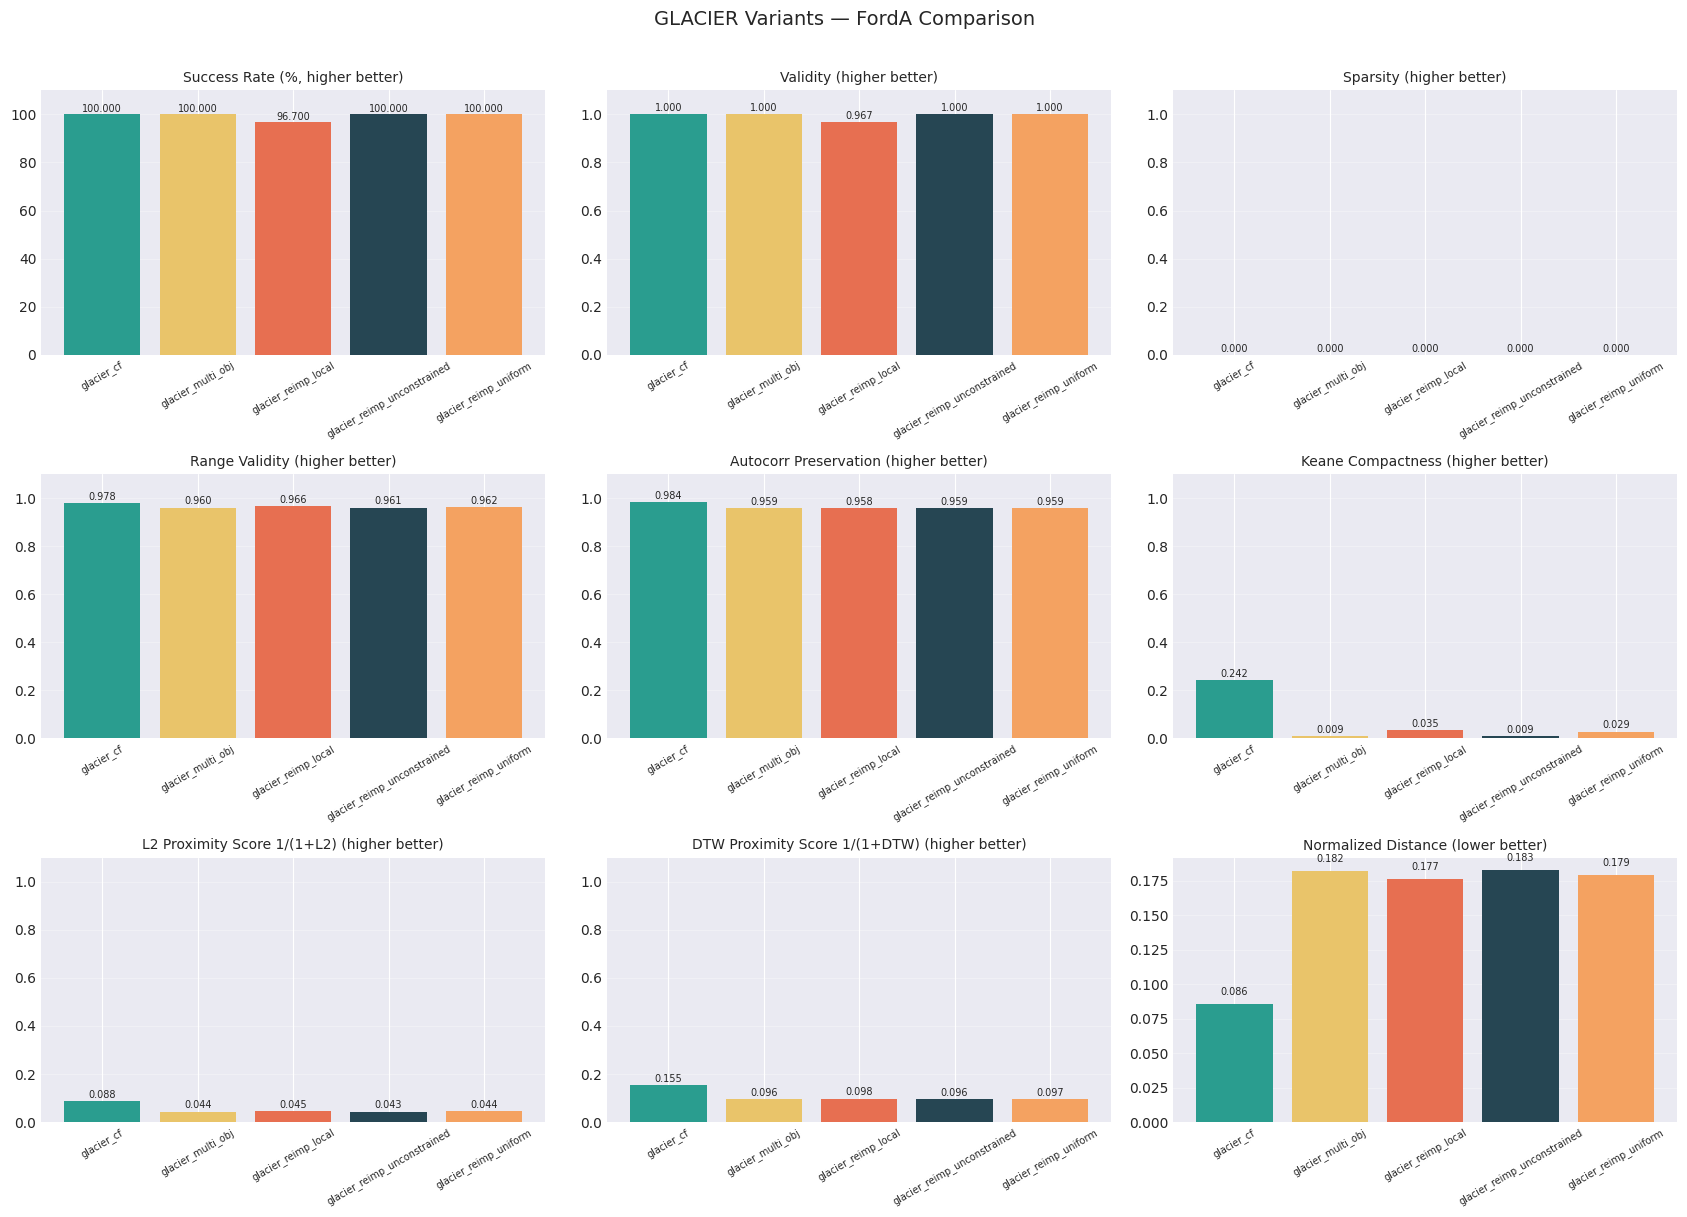

In [7]:
# Bar chart comparison across all methods
METHOD_COLORS = [
    "#2a9d8f", "#e9c46a", "#e76f51", "#264653", "#f4a261"
]

plot_df = summary_df.sort_values("method").reset_index(drop=True)
methods = plot_df["method"].tolist()
colors = METHOD_COLORS[: len(methods)]


def bar(ax, vals, title, ylim=None):
    bars = ax.bar(methods, vals, color=colors)
    ax.set_title(title, fontsize=10)
    if ylim:
        ax.set_ylim(*ylim)
    ax.tick_params(axis="x", rotation=30, labelsize=7)
    ax.grid(True, axis="y", alpha=0.3)
    for bar_, val in zip(bars, vals):
        if not np.isnan(val):
            ax.text(
                bar_.get_x() + bar_.get_width() / 2,
                bar_.get_height() + 0.005,
                f"{val:.3f}",
                ha="center", va="bottom", fontsize=7,
            )


l2_score = 1.0 / (1.0 + plot_df["l2_norm_mean"].fillna(np.inf))
dtw_score = 1.0 / (1.0 + plot_df["dtw_proximity_mean"].fillna(np.inf))

fig, axes = plt.subplots(3, 3, figsize=(17, 12))
fig.suptitle("GLACIER Variants — FordA Comparison", fontsize=14, y=1.01)

bar(axes[0, 0], plot_df["success_rate"], "Success Rate (%, higher better)", ylim=(0, 110))
bar(axes[0, 1], plot_df["validity_mean"].fillna(0), "Validity (higher better)", ylim=(0, 1.1))
bar(axes[0, 2], plot_df["sparsity_mean"].fillna(0), "Sparsity (higher better)", ylim=(0, 1.1))
bar(axes[1, 0], plot_df["range_validity_mean"].fillna(0), "Range Validity (higher better)", ylim=(0, 1.1))
bar(axes[1, 1], plot_df["autocorr_mean"].fillna(0), "Autocorr Preservation (higher better)", ylim=(0, 1.1))
bar(axes[1, 2], plot_df["keane_compactness_mean"].fillna(0), "Keane Compactness (higher better)", ylim=(0, 1.1))
bar(axes[2, 0], l2_score, "L2 Proximity Score 1/(1+L2) (higher better)", ylim=(0, 1.1))
bar(axes[2, 1], dtw_score, "DTW Proximity Score 1/(1+DTW) (higher better)", ylim=(0, 1.1))
bar(axes[2, 2], plot_df["normalized_distance_mean"].fillna(np.nan), "Normalized Distance (lower better)")

plt.tight_layout()
plt.show()

In [8]:
# Pick a representative sample where all (or as many as possible) methods succeeded
method_names = list(METHODS.keys())

success_counts = (
    results_df[results_df["sample_idx"].isin(selected_indices)]
    .groupby("sample_idx")["success"]
    .sum()
    .sort_values(ascending=False)
)

full_success = [
    int(si) for si, cnt in success_counts.items() if int(cnt) == len(method_names)
]
rep_idx = full_success[0] if full_success else int(success_counts.index[0])

print(f"Representative sample index: {rep_idx}")
print(f"Methods succeeded: {int(success_counts[rep_idx])} / {len(method_names)}")

Representative sample index: 0
Methods succeeded: 5 / 5


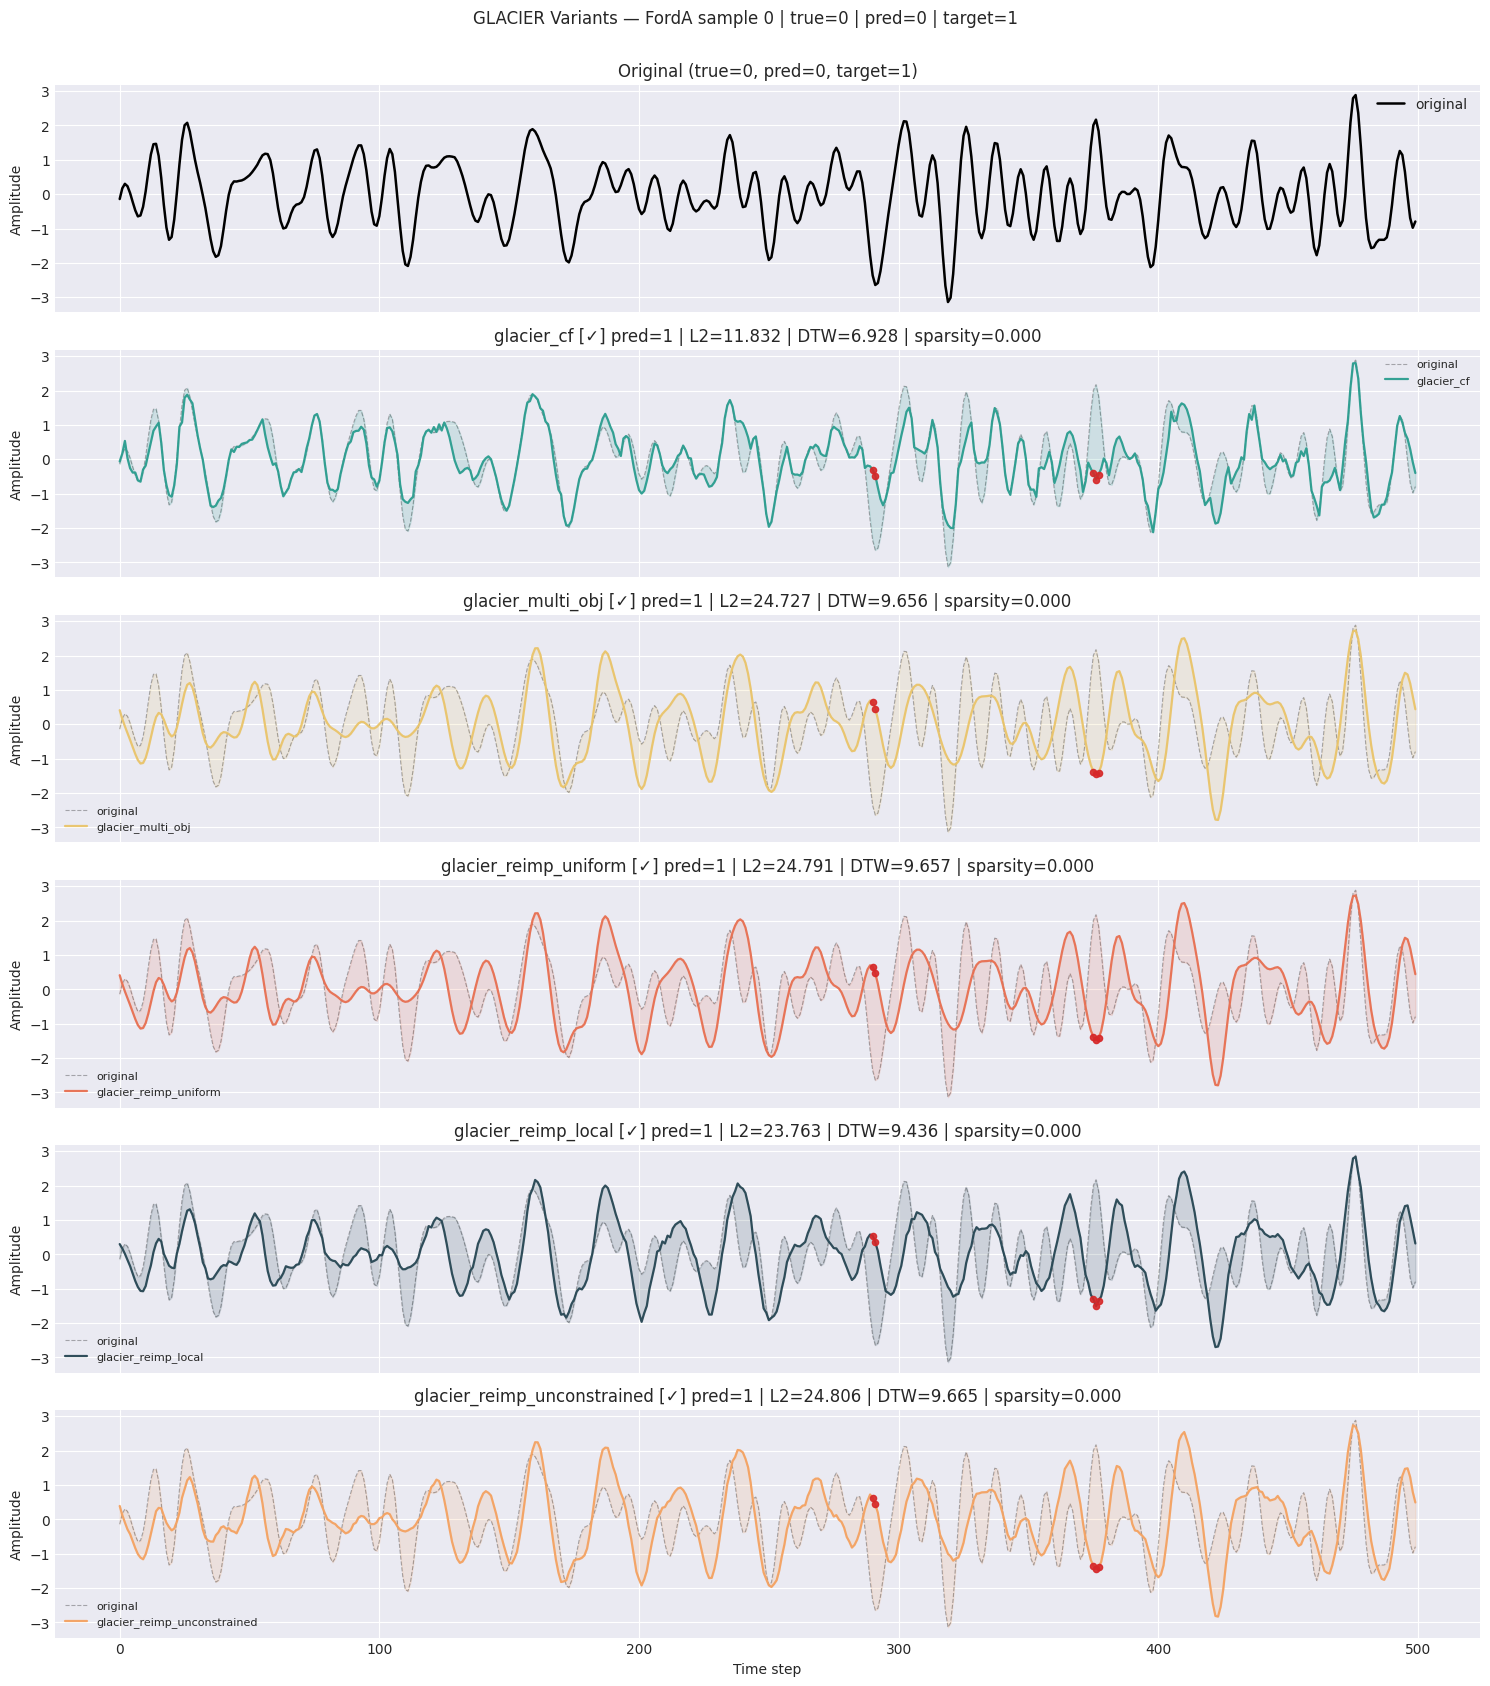

In [9]:
# Waveform comparison: original vs each GLACIER variant
rep = all_cfs[rep_idx]
x = to_channel_first(rep["sample"])[0]
x_axis = np.arange(len(x))

sample_results = results_df[results_df["sample_idx"] == rep_idx]
info_lookup = {
    row["method"]: {
        "success": bool(row["success"]),
        "pred_cf": int(row["pred_cf"]) if not pd.isna(row["pred_cf"]) else None,
        "l2": float(row["l2_norm"]) if not pd.isna(row["l2_norm"]) else np.nan,
        "dtw": float(row["dtw_proximity"]) if not pd.isna(row["dtw_proximity"]) else np.nan,
        "sparsity": float(row["sparsity"]) if not pd.isna(row["sparsity"]) else np.nan,
    }
    for _, row in sample_results.iterrows()
}

orig_row = sample_results.iloc[0]
true_label = int(orig_row["true_label"])
pred_orig = int(orig_row["pred_orig"])
target_class = int(orig_row["target_class"])

n_rows = 1 + len(method_names)
fig, axes = plt.subplots(n_rows, 1, figsize=(15, 2.8 * n_rows), sharex=True)
fig.suptitle(
    f"GLACIER Variants — FordA sample {rep_idx} | true={true_label} | pred={pred_orig} | target={target_class}",
    fontsize=12, y=1.001,
)

axes[0].plot(x, color="black", linewidth=1.8, label="original")
axes[0].set_title(f"Original (true={true_label}, pred={pred_orig}, target={target_class})")
axes[0].set_ylabel("Amplitude")
axes[0].legend(loc="best")

for i, method_name in enumerate(method_names, start=1):
    ax = axes[i]
    cf = rep.get(method_name)
    info = info_lookup.get(method_name, {})
    worked = info.get("success", False)
    pred_cf = info.get("pred_cf")
    l2_val = info.get("l2", np.nan)
    dtw_val = info.get("dtw", np.nan)
    sp_val = info.get("sparsity", np.nan)

    ax.plot(x, color="black", linewidth=0.8, linestyle="--", alpha=0.3, label="original")

    if cf is None:
        ax.text(0.5, 0.5, f"{method_name}: no CF available", ha="center", va="center", transform=ax.transAxes)
    else:
        cf_line = to_channel_first(cf)[0]
        ax.plot(cf_line, linewidth=1.6, alpha=0.95, color=METHOD_COLORS[i - 1], label=method_name)
        ax.fill_between(x_axis, x, cf_line, color=METHOD_COLORS[i - 1], alpha=0.15)
        diff_abs = np.abs(cf_line - x)
        top_idx = np.argsort(diff_abs)[-5:] if diff_abs.size >= 5 else np.arange(diff_abs.size)
        ax.scatter(x_axis[top_idx], cf_line[top_idx], s=20, color="#d62728", alpha=0.9, zorder=4)

    status = "✓" if worked else "✗"
    ax.set_title(
        f"{method_name} [{status}] pred={pred_cf} | L2={l2_val:.3f} | DTW={dtw_val:.3f} | sparsity={sp_val:.3f}"
    )
    ax.set_ylabel("Amplitude")
    ax.legend(loc="best", fontsize=8)

axes[-1].set_xlabel("Time step")
plt.tight_layout(rect=[0, 0, 1, 0.998])
plt.show()

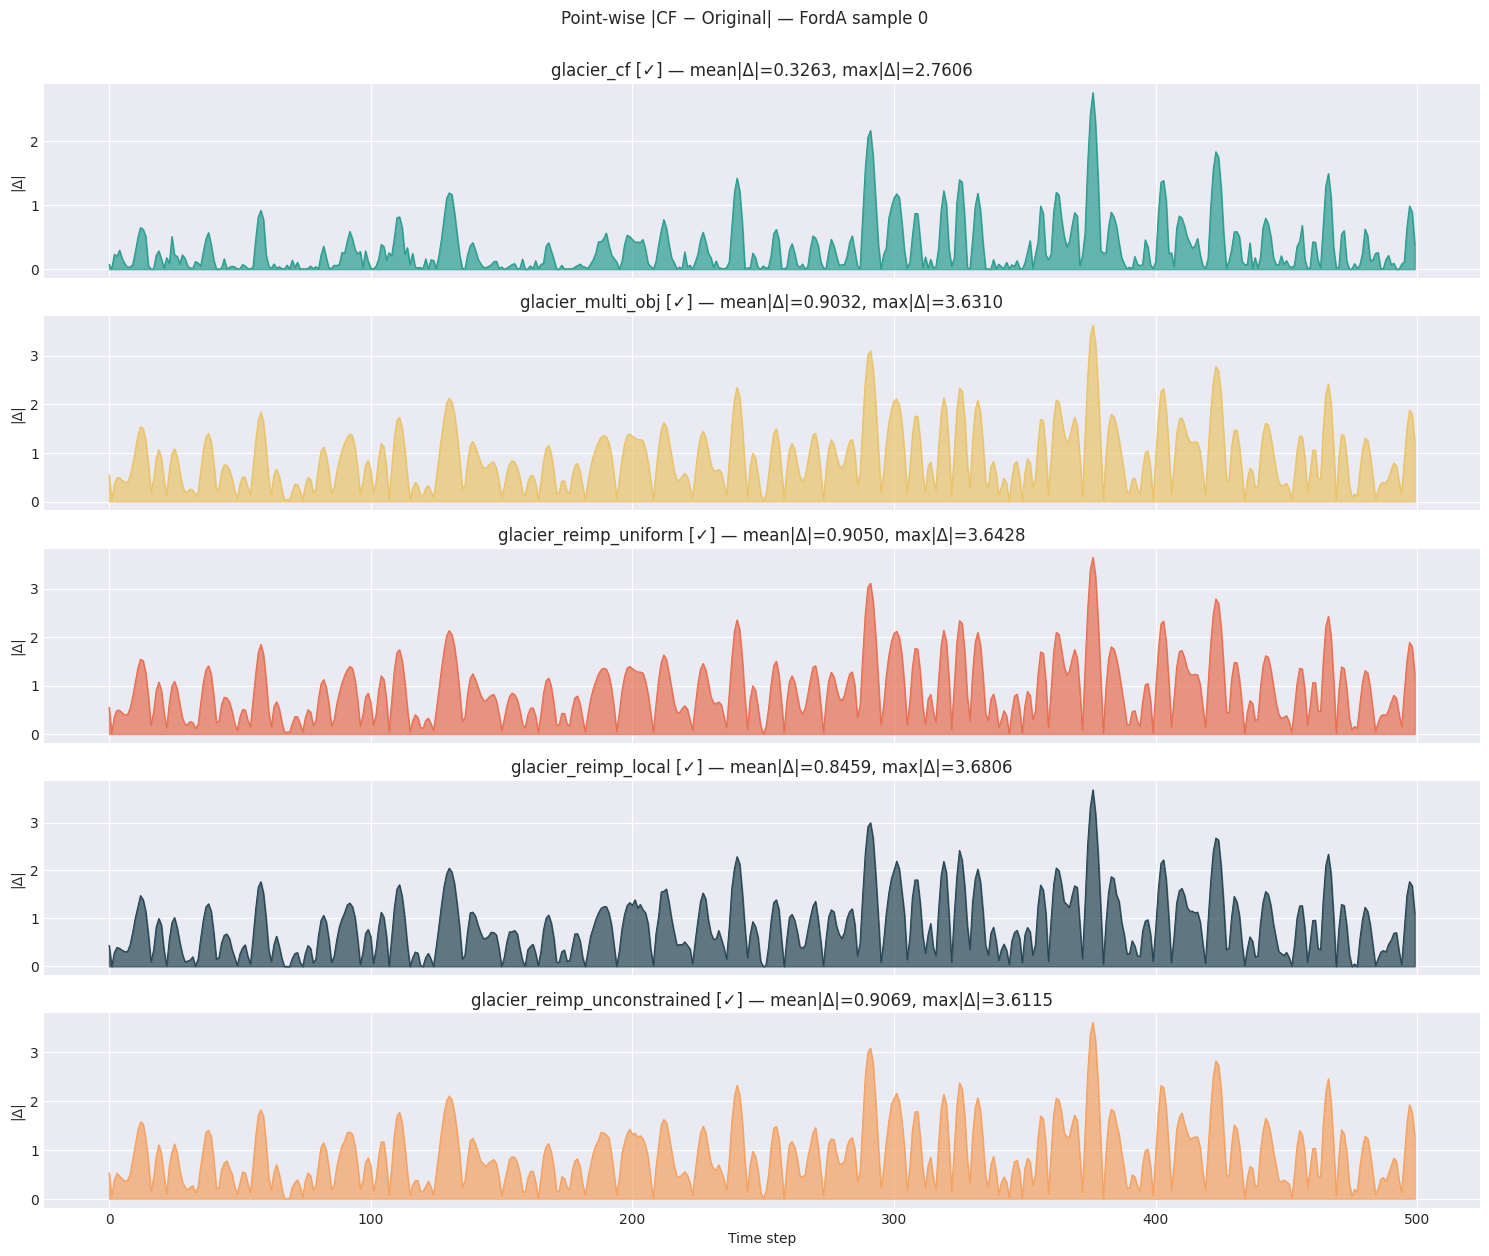

In [10]:
# Difference magnitude |CF - original| for each method on the representative sample
fig, axes = plt.subplots(len(method_names), 1, figsize=(15, 2.5 * len(method_names)), sharex=True)
fig.suptitle(
    f"Point-wise |CF − Original| — FordA sample {rep_idx}",
    fontsize=12, y=1.001,
)

for i, method_name in enumerate(method_names):
    ax = axes[i]
    cf = rep.get(method_name)
    if cf is None:
        ax.text(0.5, 0.5, f"{method_name}: no CF", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(method_name)
        continue
    diff = np.abs(to_channel_first(cf)[0] - x)
    info = info_lookup.get(method_name, {})
    worked = info.get("success", False)
    status = "✓" if worked else "✗"
    ax.fill_between(x_axis, 0, diff, color=METHOD_COLORS[i], alpha=0.7)
    ax.plot(diff, color=METHOD_COLORS[i], linewidth=0.8)
    ax.set_title(f"{method_name} [{status}] — mean|Δ|={diff.mean():.4f}, max|Δ|={diff.max():.4f}")
    ax.set_ylabel("|Δ|")

axes[-1].set_xlabel("Time step")
plt.tight_layout(rect=[0, 0, 1, 0.998])
plt.show()

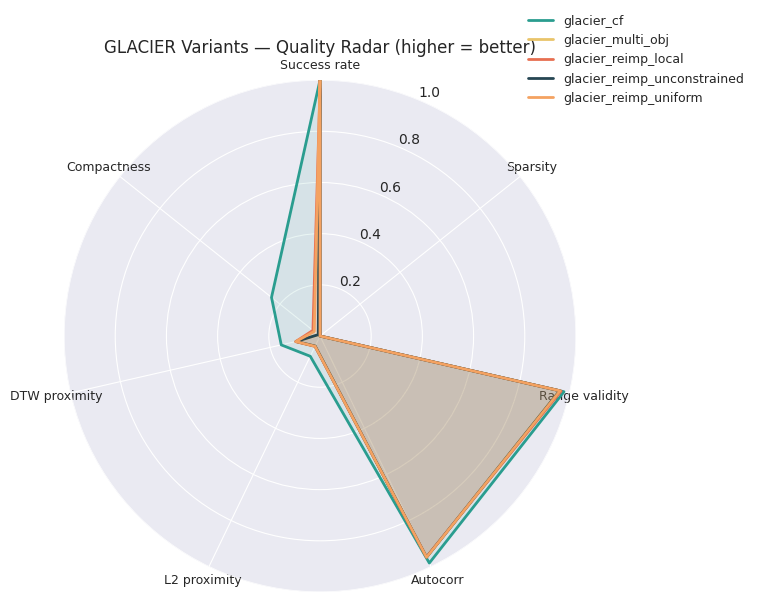

In [11]:
# Radar / spider chart summarizing key metrics (all inverted so higher=better)
radar_metrics = [
    "success_rate_norm",
    "sparsity_mean",
    "range_validity_mean",
    "autocorr_mean",
    "l2_score",
    "dtw_score",
    "keane_compactness_mean",
]
radar_labels = [
    "Success rate",
    "Sparsity",
    "Range validity",
    "Autocorr",
    "L2 proximity",
    "DTW proximity",
    "Compactness",
]

plot_df2 = plot_df.copy()
plot_df2["success_rate_norm"] = plot_df2["success_rate"] / 100.0
plot_df2["l2_score"] = 1.0 / (1.0 + plot_df2["l2_norm_mean"].fillna(np.inf))
plot_df2["dtw_score"] = 1.0 / (1.0 + plot_df2["dtw_proximity_mean"].fillna(np.inf))

N = len(radar_metrics)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, size=9)
ax.set_ylim(0, 1)

for row_i, row in plot_df2.iterrows():
    vals = [float(row.get(m, 0) or 0) for m in radar_metrics]
    vals += vals[:1]
    color = METHOD_COLORS[row_i % len(METHOD_COLORS)]
    ax.plot(angles, vals, linewidth=2, linestyle="solid", label=row["method"], color=color)
    ax.fill(angles, vals, alpha=0.1, color=color)

ax.set_title("GLACIER Variants — Quality Radar (higher = better)", pad=20, fontsize=12)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15), fontsize=9)
plt.tight_layout()
plt.show()

In [12]:
# Show any errors that occurred during evaluation
errors = results_df[results_df["error"].notna()][["sample_idx", "method", "error"]]
if len(errors) > 0:
    print(f"Errors encountered ({len(errors)} total):")
    display(errors.head(20))
else:
    print("No errors encountered.")

No errors encountered.
